<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [6]:
df = pd.read_csv(
    "bjy819_project_summary.csv",
    sep=";",
    keep_default_na=False
)

df = df.rename(columns={
    "project_wocid": "project",
    "commit_sha1": "commit",
    "commit message": "message"
})

df["Month"] = pd.to_datetime(
    df["time"], unit="s", utc=True
).dt.strftime("%Y-%m")

df.head()

,project,commit,author,time,message,Month
0,mobvoi_wenet,00068789555dbe4c6aff671288cb40ead8bf9105,Binbin Zhang <binbzha@qq.com>,1651152697,[binding]: add python binding\n,2022-04
1,mobvoi_wenet,000c7af5c36afafd3fa3ae4599af237e902c67bb,Mddct <hamddct@gmail.com>,1697436927,[cli/paraformer] ali-paraformer load and inf...,2023-10
2,mobvoi_wenet,00142a006a0845fc83e0e9b103fc9e2b1ee25420,robin1001 <robin1001@users.noreply.github.com>,1612274843,Automated deployment: Tue Feb 2 14:07:23 UTC ...,2021-02
3,mobvoi_wenet,003277de21ab47572e15e7d42d20ac8255e78fcc,Binbin Zhang <binbzha@qq.com>,1651395445,try cibuildwheel\n,2022-05
4,mobvoi_wenet,003766d4031504c1d84077211355a16896b6b6b9,zhyyao <94102052+zhyyao@users.noreply.github.com>,1657845908,[rnnt] beamsearch (#1302)\n\n* rnnt prefix bea...,2022-07


In [ ]:
for prj in df["project"].unique():
    # Monthly counts — same approach as the starter
    df1 = df[df["project"] == prj]
    df2 = df1.groupby("Month").size().reset_index(name="Commits")
    monthly_counts = df2.copy()

    monthly_counts["time"] = pd.to_datetime(monthly_counts["Month"])

    full_date_range = pd.DataFrame({
        "time": pd.date_range(
            start=monthly_counts["time"].min(),
            end=monthly_counts["time"].max(),
            freq="MS"
        )
    })

    monthly_counts = pd.merge(
        full_date_range, monthly_counts, on="time", how="left"
    )

    monthly_counts["Commits"] = (
        monthly_counts["Commits"].fillna(0).astype(int)
    )
    monthly_counts["Month"] = (
        monthly_counts["time"].dt.strftime("%Y-%m")
    )

    # Save the required two-column monthly CSV
    monthly_counts[["Month", "Commits"]].rename(
        columns={"Commits": "#Commits"}
    ).to_csv(
        "bjy819_commits_timeseries_" + prj + ".csv",
        sep=";",
        index=False
    )

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(
        monthly_counts["Month"],
        monthly_counts["Commits"],
        marker="o",
        linestyle="-"
    )
    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title(prj)
    plt.grid(True)

    # Show approximately 12 date labels for readability
    step = max(1, len(monthly_counts) // 12)
    plt.xticks(
        range(0, len(monthly_counts), step),
        monthly_counts["Month"].iloc[::step],
        rotation=45,
        fontsize=7
    )

    plt.tight_layout()
    plt.savefig("bjy819_timeseries_" + prj + ".png", dpi=600)
    plt.show()
    plt.close()

    print(f"Saved monthly CSV and graph for {prj}")


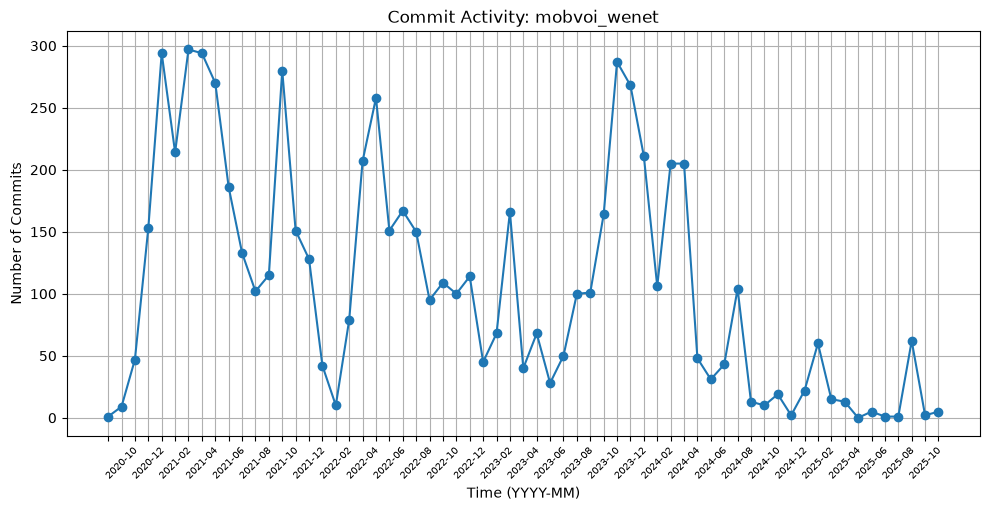

In [9]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("your-net-id-here_timeseries_"+prj+".png", dpi=600)
plt.show()
plt.close()

# Identify the Longest Inactivity Gap


Add all that info to netid_project_stats.csv